In [ ]:
from google.colab import files
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
uploaded = files.upload()

Saving archive (13).zip to archive (13) (1).zip


In [ ]:
with zipfile.ZipFile('archive (13) (1).zip','r') as z :
  z.extractall('zomato_data')
  print("Files Extracted Successfully!")

Files Extracted Successfully!


Loading Data

In [ ]:
df = pd.read_csv('zomato_data/zomato.csv',encoding='latin-1')
df_country = pd.read_excel('zomato_data/Country-Code.xlsx')

In [ ]:
final_df = pd.merge(df,df_country, on = 'Country Code', how ='left')
india_df = final_df[final_df['Country'] == 'India'].copy()
india_df.dropna(subset = ['Cuisines'],inplace = True)
india_df.reset_index(drop = True, inplace = True)


Summary

In [ ]:
print("\n Data Ready! Here's your summary:")
print(f"Total Indian Resturants : {india_df.shape[0]}")
print(f"Total Cities : {india_df['City'].nunique()}")
print(f"Average Rating : {india_df['Aggregate rating'].mean():.2f}")
print(f"Average Cost for Two : Rs {india_df['Average Cost for two'].mean():.0f}")



 Data Ready! Here's your summary:
Total Indian Resturants : 8652
Total Cities : 43
Average Rating : 2.52
Average Cost for Two : Rs 623


Chart 1 — Top 10 Cities by Number of Restaurants

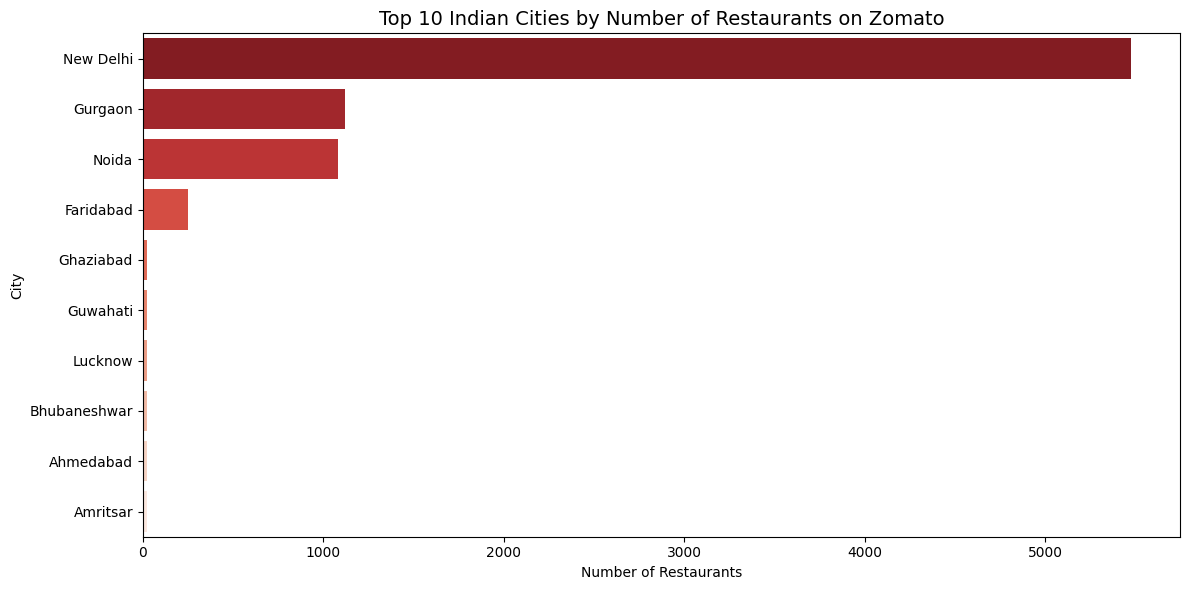

In [ ]:
plt.figure(figsize=(12,6))
city_counts = india_df['City'].value_counts().head(10)
sns.barplot(x=city_counts.values, y=city_counts.index, palette ='Reds_r', hue=city_counts.index, legend=False)
plt.title('Top 10 Indian Cities by Number of Restaurants on Zomato',fontsize = 14)
plt.xlabel('Number of Restaurants')
plt.ylabel('City')
plt.tight_layout()
plt.savefig('Chart1_top_cities.png', dpi = 150)
plt.show()


Chart 2 — Average Rating by Top 10 Cities

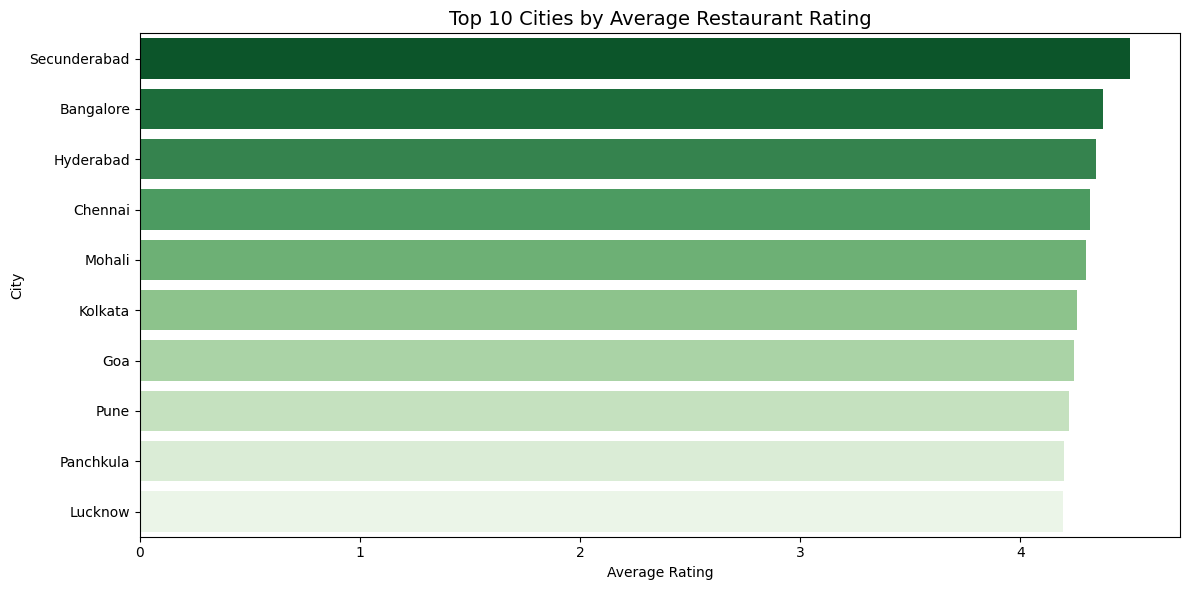

In [ ]:
plt.figure(figsize=(12,6))
city_ratings = india_df.groupby('City')['Aggregate rating'].mean().sort_values(ascending = False).head(10)
sns.barplot(x=city_ratings.values, y=city_ratings.index, palette ='Greens_r', hue=city_ratings.index, legend=False)
plt.title('Top 10 Cities by Average Restaurant Rating', fontsize = 14)
plt.xlabel('Average Rating')
plt.ylabel('City')
plt.tight_layout()
plt.savefig('chart2_city_ratings.png', dpi =150)
plt.show()

Chart 3 — Top 10 Most Popular Cuisines

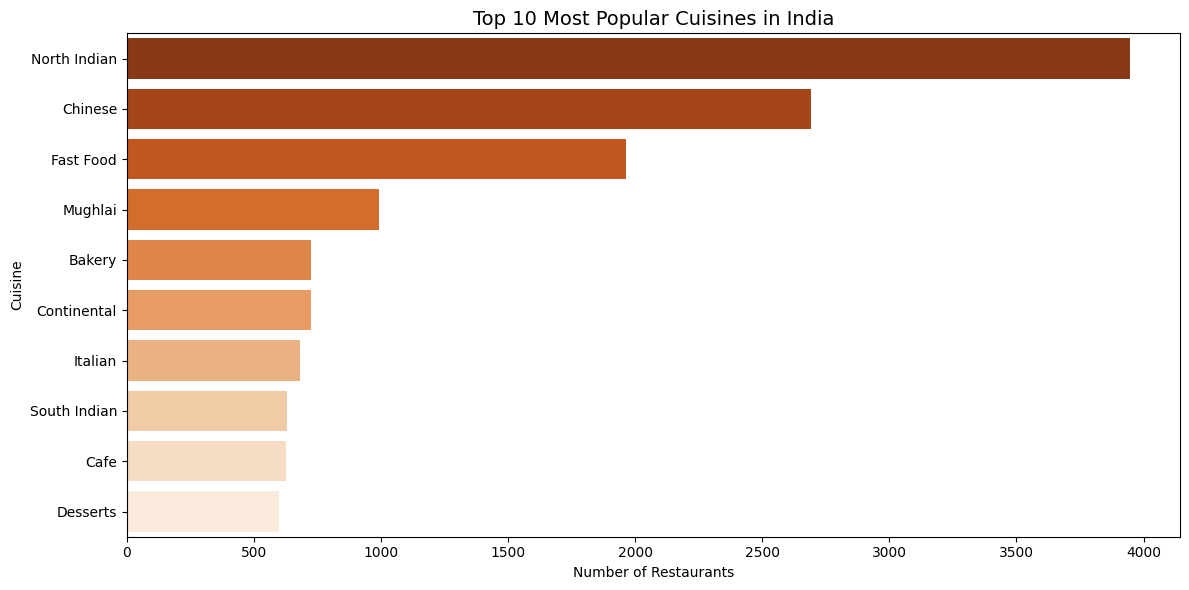

In [ ]:
plt.figure(figsize = (12,6))
cusines = india_df['Cuisines'].str.split(',').explode().str.strip()
top_cuisines = cusines.value_counts().head(10)
sns.barplot(x= top_cuisines.values, y= top_cuisines.index, palette = 'Oranges_r', hue=top_cuisines.index, legend=False)
plt.title('Top 10 Most Popular Cuisines in India', fontsize = 14)
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.savefig('chart3_cuisines.png', dpi = 150)
plt.show()

Chart 4 — Online Delivery Adoption

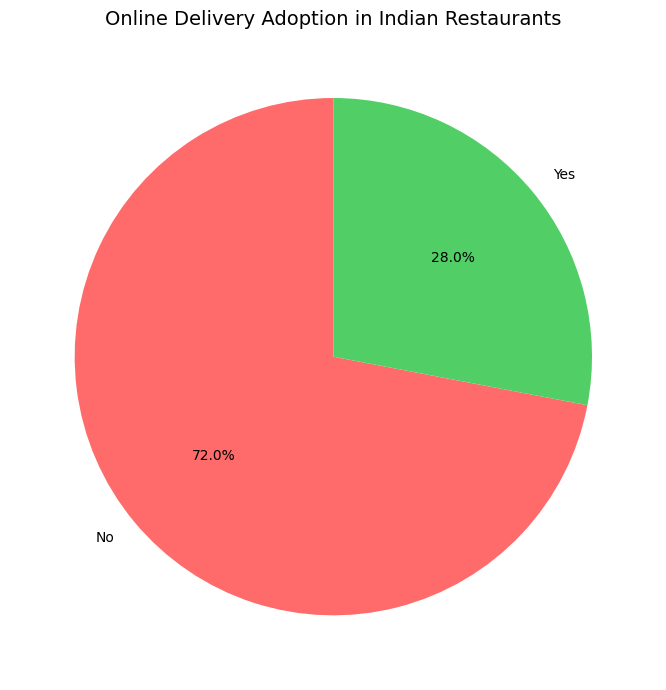

In [ ]:
plt.figure(figsize = (7,7))
delivery = india_df['Has Online delivery'].value_counts()
plt.pie(delivery.values, labels = delivery.index, autopct ='%1.1f%%',
        colors = ['#ff6b6b','#51cf66'], startangle = 90)
plt.title('Online Delivery Adoption in Indian Restaurants', fontsize =14)
plt.tight_layout()
plt.savefig('chart4_online_delivery.png',dpi = 150)
plt.show()

Chart 5 - Price Range vs Average Rating

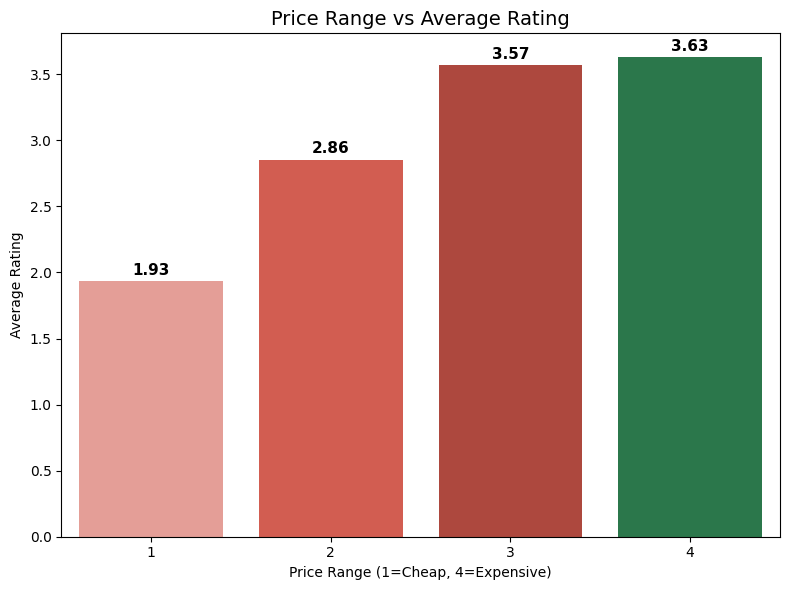

In [ ]:
plt.figure(figsize=(8,6))
price_rating = india_df.groupby('Price range')['Aggregate rating'].mean()
colors = ['#F1948A', '#E74C3C', '#C0392B', '#1E8449']  # light red → dark red → green
sns.barplot(x=price_rating.index, y=price_rating.values, palette=colors, hue=price_rating.index, legend=False)
plt.title('Price Range vs Average Rating', fontsize=14)
plt.xlabel('Price Range (1=Cheap, 4=Expensive)')
plt.ylabel('Average Rating')

for i, v in enumerate(price_rating.values):
    plt.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('chart5_price_rating.png', dpi=150)
plt.show()

Chart 6 - Rating Distribution


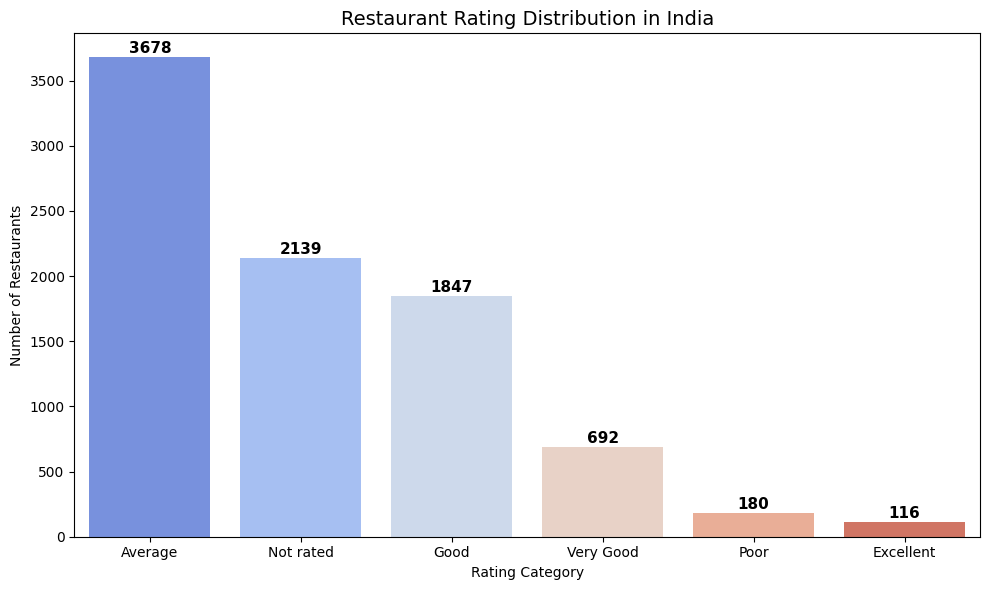

In [ ]:
plt.figure(figsize=(10,6))
rating_dist = india_df['Rating text'].value_counts()
ax = sns.barplot(x=rating_dist.index, y=rating_dist.values, palette='coolwarm', hue=rating_dist.index, legend=False)
plt.title('Restaurant Rating Distribution in India', fontsize=14)
plt.xlabel('Rating Category')
plt.ylabel('Number of Restaurants')

for i, v in enumerate(rating_dist.values):
    ax.text(i, v + 30, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('chart6_rating_distribution.png', dpi=150)
plt.show()